https://www.tensorflow.org/probability/examples/Eight_Schools

In [5]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

import tensorflow.compat.v2 as tf
import tensorflow_probability as tfp
from tensorflow_probability import distributions as tfd
import warnings

tf.enable_v2_behavior()

plt.style.use("ggplot")
warnings.filterwarnings('ignore')

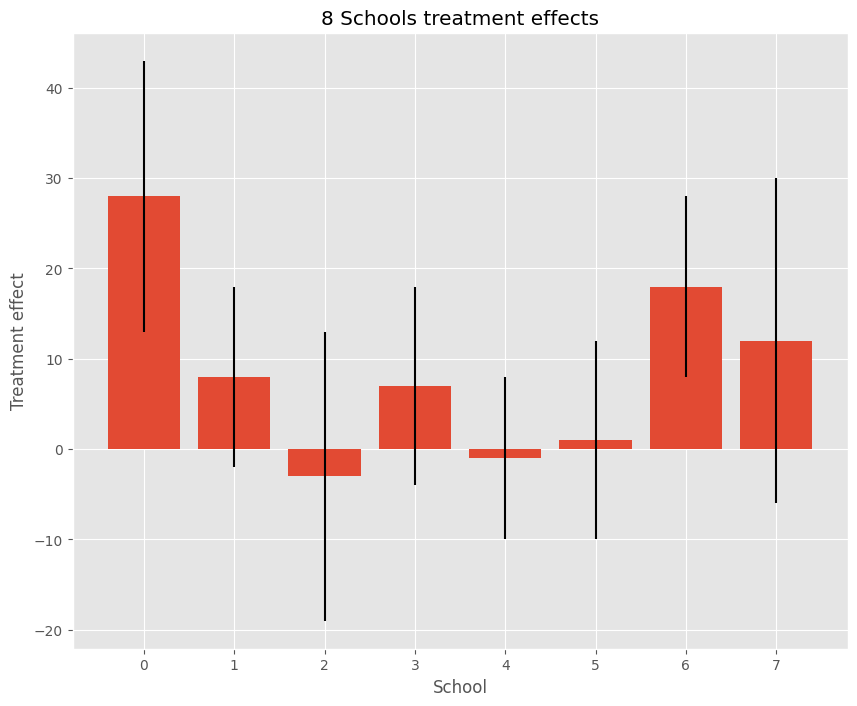

In [6]:
num_schools = 8  # number of schools
treatment_effects = np.array(
    [28, 8, -3, 7, -1, 1, 18, 12], dtype=np.float32)  # treatment effects
treatment_stddevs = np.array(
    [15, 10, 16, 11, 9, 11, 10, 18], dtype=np.float32)  # treatment SE

fig, ax = plt.subplots()
plt.bar(range(num_schools), treatment_effects, yerr=treatment_stddevs)
plt.title("8 Schools treatment effects")
plt.xlabel("School")
plt.ylabel("Treatment effect")
fig.set_size_inches(10, 8)
plt.show()

In [7]:
model = tfd.JointDistributionSequential([
  tfd.Normal(loc=0., scale=10., name="avg_effect"),  # `mu` above
  tfd.Normal(loc=5., scale=1., name="avg_stddev"),  # `log(tau)` above
  tfd.Independent(tfd.Normal(loc=tf.zeros(num_schools),
                             scale=tf.ones(num_schools),
                             name="school_effects_standard"),  # `theta_prime` 
                  reinterpreted_batch_ndims=1),
  lambda school_effects_standard, avg_stddev, avg_effect: (
      tfd.Independent(tfd.Normal(loc=(avg_effect[..., tf.newaxis] +
                                      tf.exp(avg_stddev[..., tf.newaxis]) *
                                      school_effects_standard),  # `theta` above
                                 scale=treatment_stddevs),
                      name="treatment_effects",  # `y` above
                      reinterpreted_batch_ndims=1))
])

def target_log_prob_fn(avg_effect, avg_stddev, school_effects_standard):
  """Unnormalized target density as a function of states."""
  return model.log_prob((
      avg_effect, avg_stddev, school_effects_standard, treatment_effects))

In [11]:
num_results = 8000
num_burnin_steps = 2000

# Improve performance by tracing the sampler using `tf.function`
# and compiling it using XLA.
@tf.function(autograph=False, jit_compile=True)
def do_sampling():
  return tfp.mcmc.sample_chain(
      num_results=num_results,
      num_burnin_steps=num_burnin_steps,
      current_state=[
          tf.zeros([], name='init_avg_effect'),
          tf.zeros([], name='init_avg_stddev'),
          tf.ones([num_schools], name='init_school_effects_standard'),
      ],
      kernel=tfp.mcmc.HamiltonianMonteCarlo(
          target_log_prob_fn=target_log_prob_fn,
          step_size=0.4,
          num_leapfrog_steps=3))

states, kernel_results = do_sampling()

avg_effect, avg_stddev, school_effects_standard = states

school_effects_samples = (
    avg_effect[:, np.newaxis] +
    np.exp(avg_stddev)[:, np.newaxis] * school_effects_standard)

num_accepted = np.sum(kernel_results.is_accepted)
print('Acceptance rate: {}'.format(num_accepted / num_results))

Acceptance rate: 0.59725


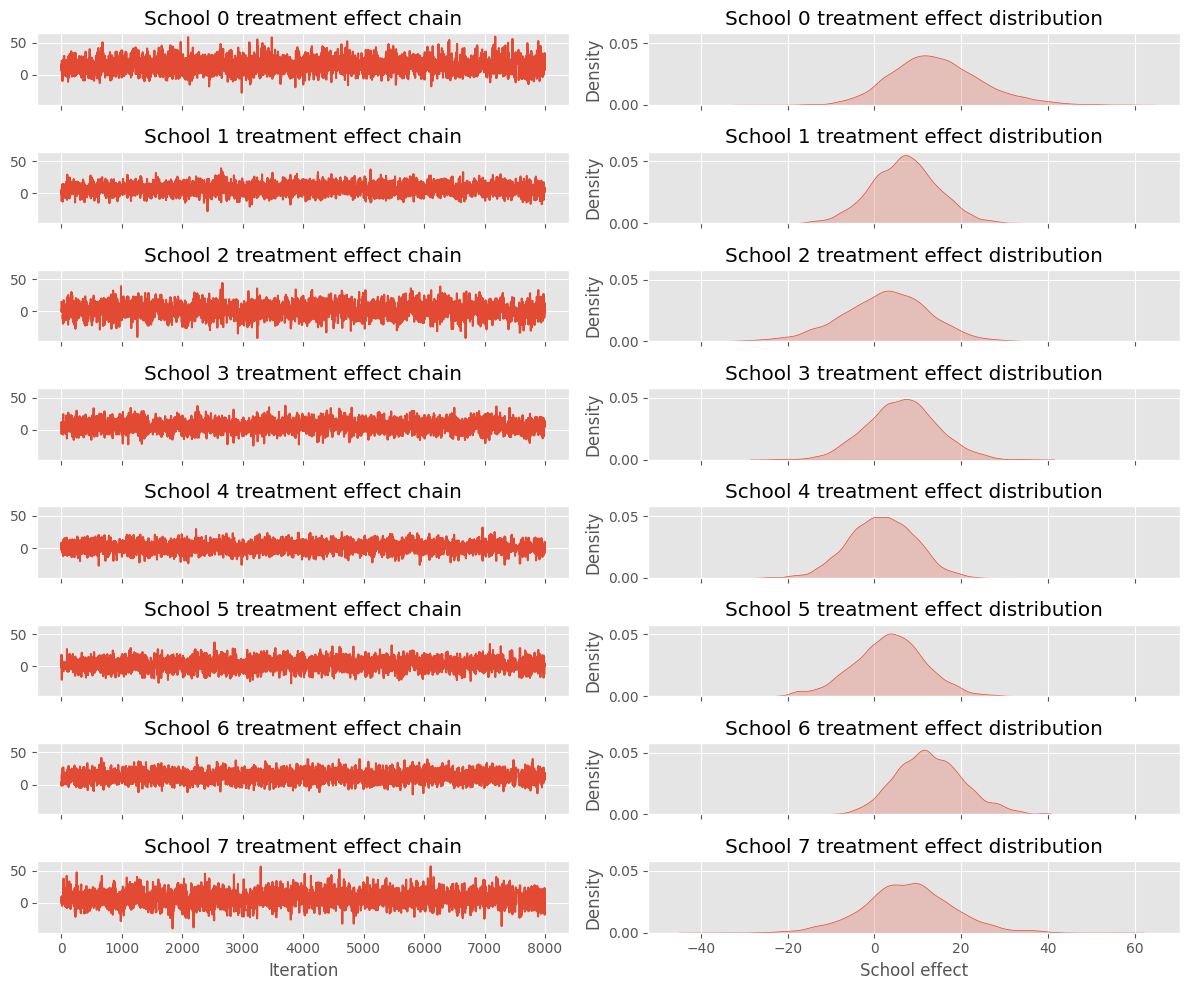

In [12]:
fig, axes = plt.subplots(8, 2, sharex='col', sharey='col')
fig.set_size_inches(12, 10)
for i in range(num_schools):
  axes[i][0].plot(school_effects_samples[:,i].numpy())
  axes[i][0].title.set_text("School {} treatment effect chain".format(i))
  sns.kdeplot(school_effects_samples[:,i].numpy(), ax=axes[i][1], shade=True)
  axes[i][1].title.set_text("School {} treatment effect distribution".format(i))
axes[num_schools - 1][0].set_xlabel("Iteration")
axes[num_schools - 1][1].set_xlabel("School effect")
fig.tight_layout()
plt.show()

In [13]:
print("E[avg_effect] = {}".format(np.mean(avg_effect)))
print("E[avg_stddev] = {}".format(np.mean(avg_stddev)))
print("E[school_effects_standard] =")
print(np.mean(school_effects_standard[:, ]))
print("E[school_effects] =")
print(np.mean(school_effects_samples[:, ], axis=0))

E[avg_effect] = 5.210880756378174
E[avg_stddev] = 2.457479476928711
E[school_effects_standard] =
0.11153723
E[school_effects] =
[14.292956   6.9326367  2.421706   6.251806   1.611494   3.4103055
 12.775029   7.6614394]


In [14]:
# Compute the 95% interval for school_effects
school_effects_low = np.array([
    np.percentile(school_effects_samples[:, i], 2.5) for i in range(num_schools)
])
school_effects_med = np.array([
    np.percentile(school_effects_samples[:, i], 50) for i in range(num_schools)
])
school_effects_hi = np.array([
    np.percentile(school_effects_samples[:, i], 97.5)
    for i in range(num_schools)
])

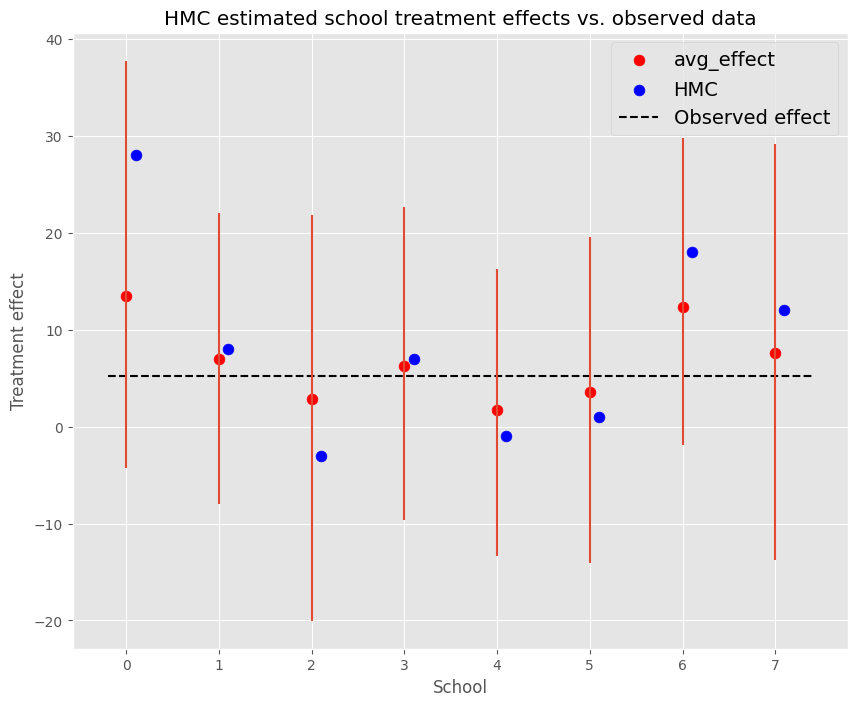

In [15]:
fig, ax = plt.subplots(nrows=1, ncols=1, sharex=True)
ax.scatter(np.array(range(num_schools)), school_effects_med, color='red', s=60)
ax.scatter(
    np.array(range(num_schools)) + 0.1, treatment_effects, color='blue', s=60)

plt.plot([-0.2, 7.4], [np.mean(avg_effect),
                       np.mean(avg_effect)], 'k', linestyle='--')

ax.errorbar(
    np.array(range(8)),
    school_effects_med,
    yerr=[
        school_effects_med - school_effects_low,
        school_effects_hi - school_effects_med
    ],
    fmt='none')

ax.legend(('avg_effect', 'HMC', 'Observed effect'), fontsize=14)

plt.xlabel('School')
plt.ylabel('Treatment effect')
plt.title('HMC estimated school treatment effects vs. observed data')
fig.set_size_inches(10, 8)
plt.show()

In [16]:
print("Inferred posterior mean: {0:.2f}".format(
    np.mean(school_effects_samples[:,])))
print("Inferred posterior mean se: {0:.2f}".format(
    np.std(school_effects_samples[:,])))

Inferred posterior mean: 6.92
Inferred posterior mean se: 10.03


In [18]:
sample_shape = [8000]

_, _, _, predictive_treatment_effects = model.sample(
    value=(tf.broadcast_to(np.mean(avg_effect, 0), sample_shape),
           tf.broadcast_to(np.mean(avg_stddev, 0), sample_shape),
           tf.broadcast_to(np.mean(school_effects_standard, 0),
                           sample_shape + [num_schools]),
           None))

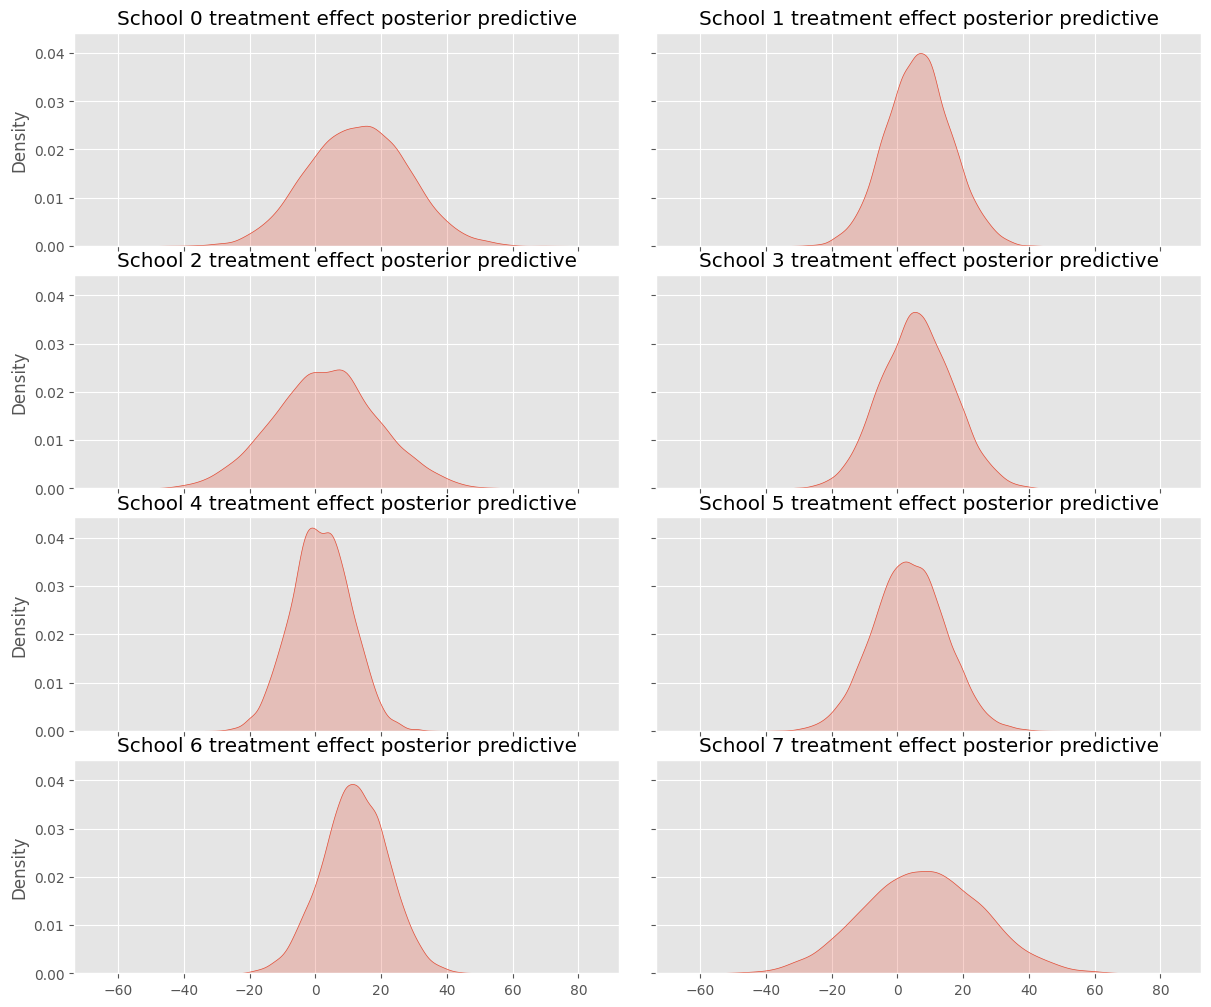

In [19]:
fig, axes = plt.subplots(4, 2, sharex=True, sharey=True)
fig.set_size_inches(12, 10)
fig.tight_layout()
for i, ax in enumerate(axes):
  sns.kdeplot(predictive_treatment_effects[:, 2*i].numpy(),
              ax=ax[0], shade=True)
  ax[0].title.set_text(
      "School {} treatment effect posterior predictive".format(2*i))
  sns.kdeplot(predictive_treatment_effects[:, 2*i + 1].numpy(),
              ax=ax[1], shade=True)
  ax[1].title.set_text(
      "School {} treatment effect posterior predictive".format(2*i + 1))
plt.show()